In [ ]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.stats import norm
from pathlib import Path
from skew.utils import (
    bs_delta, bs_price_forward, iv_at_target_delta,
    fit_svi_slice, eval_svi_iv,
)
from skew.data_store import load_option_snapshots, list_snapshots

# ===============================
# CONFIG
# ===============================
TICKER          = "NVDA"                  # single ticker for PDF surface
TICKERS         = ['NVDA', 'QQQ', 'MSFT', 'TSM']   # for skew table
# Set to "YYYY-MM-DD" to load a specific snapshot, or None for the latest
SNAPSHOT_DATE   = None
SMOOTH_S        = 1e-1
EVAL_K_GRID     = 100

# Auto-detect project root
_cwd = Path(os.getcwd())
if (_cwd / "skew").exists():
    _project_root = _cwd
elif (_cwd.parent / "skew").exists():
    _project_root = _cwd.parent
else:
    _project_root = _cwd
DB_PATH = str(_project_root / "data" / "options.db")
print(f"DB path: {DB_PATH}")

In [ ]:
# ---------- 1) Implied curve construction on a common k-grid ----------
def build_iv_surface_on_k(smiles_by_expiry, forwards, maturities, disc_factors,
                          k_lo=-0.8, k_hi=0.8, Nk=201, iv_clip=(1e-4, 5.0)):
    """
    Inputs:
      smiles_by_expiry: list of DataFrames with columns ['strike','iv'] per expiry.
                        Should contain OTM options (puts below F, calls above F)
                        for best SVI fit quality.
      forwards:   array-like F_i
      maturities: array-like T_i (years)
      disc_factors: array-like D_i = exp(-r_i T_i)

    Per-expiry interpolation uses a raw-SVI parametrization (convex by construction,
    extrapolates smoothly) with PCHIP as a fallback when fewer than 5 points are available.
    """
    M = len(maturities)
    k_grid = np.linspace(k_lo, k_hi, Nk)
    Kmat   = np.zeros((M, Nk))
    SIGMA  = np.zeros((M, Nk))

    for i in range(M):
        F, T = float(forwards[i]), float(maturities[i])
        K_target = F * np.exp(k_grid)
        Kmat[i, :] = K_target

        df = smiles_by_expiry[i].copy()
        df = df[np.isfinite(df['strike']) & np.isfinite(df['iv']) & (df['strike'] > 0) & (df['iv'] > 0)]

        if len(df) < 2:
            iv_fill = np.clip(np.nanmedian(df['iv']), *iv_clip) if len(df) > 0 else 0.2
            SIGMA[i, :] = iv_fill
            continue

        df = df.sort_values('strike')
        K_in  = df['strike'].values
        iv_in = np.clip(df['iv'].values, *iv_clip)

        iv_eval = None

        # ── Try SVI first (convex smile, natural extrapolation) ───────────────
        if len(df) >= 5:
            params = fit_svi_slice(K_in, iv_in, F, T)
            if params is not None:
                iv_eval = eval_svi_iv(params, K_target, F, T)

        # ── Fallback: PCHIP with flat-wing extrapolation ───────────────────────
        if iv_eval is None:
            pchip = PchipInterpolator(K_in, iv_in, extrapolate=False)
            iv_eval = pchip(K_target)
            if np.isnan(iv_eval).any():
                valid = np.where(np.isfinite(iv_eval))[0]
                if len(valid) == 0:
                    iv_eval = np.full_like(K_target, np.nanmedian(iv_in))
                else:
                    first, last = valid[0], valid[-1]
                    iv_eval[:first] = iv_eval[first]
                    iv_eval[last + 1:] = iv_eval[last]

        SIGMA[i, :] = np.clip(iv_eval, *iv_clip)

    meta = dict(forwards=np.asarray(forwards, float),
                discounts=np.asarray(disc_factors, float),
                maturities=np.asarray(maturities, float))
    return Kmat, SIGMA, meta


# ---------- 2) Pricing surface from IV surface ----------
def price_surface_from_iv(Kmat, SIGMA, meta):
    F = meta['forwards']; D = meta['discounts']; T = meta['maturities']
    M, Nk = SIGMA.shape
    Cmat = np.zeros_like(SIGMA)
    for i in range(M):
        Cmat[i, :] = np.array([
            bs_price_forward(True, F[i], K, sigma, T[i], D[i])
            for K, sigma in zip(Kmat[i, :], SIGMA[i, :])
        ])
    return Cmat


# ---------- 3) PDF surface via numeric second derivative ----------
def pdf_surface_from_prices(Kmat, Cmat, meta, clip_neg=True, renormalize=True):
    """f(K,T) = (1/D(T)) * C''(K)  via central differences."""
    D = meta['discounts']
    M, Nk = Cmat.shape
    PDF = np.zeros_like(Cmat)

    for i in range(M):
        K = Kmat[i, :]
        C = Cmat[i, :]
        if not np.allclose(np.diff(K), np.diff(K)[0], rtol=1e-5, atol=1e-8):
            Cpp = np.empty_like(C)
            Cpp[0] = (C[2] - 2*C[1] + C[0]) / ((K[1]-K[0])**2)
            for j in range(1, Nk-1):
                h1 = K[j] - K[j-1]; h2 = K[j+1] - K[j]
                Cpp[j] = 2 * ((C[j+1]-C[j])/(h2*(h1+h2)) - (C[j]-C[j-1])/(h1*(h1+h2)))
            Cpp[-1] = (C[-1] - 2*C[-2] + C[-3]) / ((K[-2]-K[-3])**2)
        else:
            h = K[1] - K[0]
            Cpp = np.empty_like(C)
            Cpp[1:-1] = (C[2:] - 2*C[1:-1] + C[:-2]) / (h*h)
            Cpp[0]    = (C[2] - 2*C[1] + C[0]) / (h*h)
            Cpp[-1]   = (C[-1] - 2*C[-2] + C[-3]) / (h*h)

        f = (1.0 / max(D[i], 1e-16)) * Cpp
        if clip_neg:
            f = np.clip(f, 0.0, None)
        if renormalize:
            area = np.trapz(f, K)
            if area > 1e-12:
                f /= area
        PDF[i, :] = f
    return PDF


# ===============================
# PLOTTING
# ===============================
def plot_heatmap(X, Y, Z, title, xlab, ylab, cbarlab):
    plt.figure(figsize=(9, 6))
    plt.imshow(Z, origin="lower", aspect="auto",
               extent=[X.min(), X.max(), Y.min(), Y.max()])
    cb = plt.colorbar(); cb.set_label(cbarlab)
    plt.xlabel(xlab); plt.ylabel(ylab); plt.title(title)
    plt.tight_layout(); plt.show()


def plot_expiry_slices(Kmat, grid_T, SIGMA, F, n=6):
    Kmat = np.asarray(Kmat); grid_T = np.asarray(grid_T); SIGMA = np.asarray(SIGMA)
    M, N = Kmat.shape
    idx = np.unique(np.linspace(0, M - 1, min(n, M), dtype=int))
    plt.figure(figsize=(9, 4))
    plt.subplot(1, 2, 1)
    for i in idx:
        plt.plot(Kmat[i, :], SIGMA[i, :], label=f"T={grid_T[i]:.3f}y")
    plt.title("IV vs Strike (SVI slices)"); plt.xlabel("Strike K"); plt.ylabel("Implied Vol")
    plt.legend(fontsize=8)
    plt.subplot(1, 2, 2)
    if F is not None:
        F = np.asarray(F)
        for i in idx:
            plt.plot(Kmat[i, :] / F[i], SIGMA[i, :], label=f"T={grid_T[i]:.3f}y")
        plt.xlabel("Moneyness K/F"); plt.ylabel("Implied Vol")
        plt.title("IV vs Moneyness (SVI slices)"); plt.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def plot_pdf_slices(Kmat, grid_T, F, n=6, normalize=True):
    Kmat = np.asarray(Kmat); grid_T = np.asarray(grid_T); F = np.asarray(F)
    M, N = Kmat.shape
    idx = np.unique(np.linspace(0, M - 1, min(n, M), dtype=int))
    plt.figure(figsize=(8, 5))
    for i in idx:
        K = Kmat[i, :]; pdf = F[i, :]
        if normalize:
            area = np.trapz(pdf, K)
            if area > 0: pdf = pdf / area
        plt.plot(K, pdf, label=f"T = {grid_T[i]:.3f}y")
    plt.title("Risk-Neutral PDF by Expiry (SVI surface)")
    plt.xlabel("Strike (K)"); plt.ylabel("Density")
    plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
def load_and_normalise(ticker, db_path=DB_PATH, snapshot_date=None):
    """Load a snapshot from the DB and map column names to this notebook's convention."""
    raw = load_option_snapshots(ticker, db_path=db_path, snapshot_date=snapshot_date)
    if raw.empty:
        raise RuntimeError(
            f"No data for {ticker} in {db_path}. "
            "Run fetch_opt_data.ipynb first."
        )
    snap = snapshot_date or raw["snapshot_date"].max()
    df = raw[raw["snapshot_date"] == snap].copy()
    print(f"Loaded {len(df)} rows  |  {ticker}  |  snapshot={snap}")

    # Map DB canonical names back to notebook convention
    df = df.rename(columns={
        "implied_vol":      "iv",
        "underlying_price": "spot",
        "option_price":     "lastPrice",
    })
    # DB stores "C" / "P" — handle both formats
    if "option_type" in df.columns and "isCall" not in df.columns:
        ot = df["option_type"].str.upper().str.strip()
        df["isCall"] = ot.isin(["C", "CALL"])

    df["expiry"] = pd.to_datetime(df["expiry"])
    if "T" not in df.columns and "days_to_expiry" in df.columns:
        df["T"] = df["days_to_expiry"] / 365.0
    if "disc_factor" not in df.columns:
        df["disc_factor"] = 1.0
    if "forward" not in df.columns:
        df["forward"] = df["spot"]
    if "div_yield" not in df.columns:
        df["div_yield"] = 0.0

    return df

In [ ]:
# ===============================
# MAIN: load from DB → SVI surface → pdf → plots
# ===============================
df_opt = load_and_normalise(TICKER, db_path=DB_PATH, snapshot_date=SNAPSHOT_DATE)

spot = float(df_opt["spot"].iloc[0])

# Per-expiry scalars
expiries     = sorted(df_opt["expiry"].unique())
forwards     = df_opt.groupby("expiry")["forward"].first().loc[expiries].values
grid_T       = df_opt.groupby("expiry")["T"].first().loc[expiries].values
disc_factors = df_opt.groupby("expiry")["disc_factor"].first().loc[expiries].values

# OTM options for SVI: puts below forward, calls at/above forward
df_calls = df_opt[df_opt["isCall"] == True].copy()
df_puts  = df_opt[df_opt["isCall"] == False].copy()

smiles_by_expiry = []
for exp, F_exp in zip(expiries, forwards):
    calls_otm = df_calls[(df_calls["expiry"] == exp) & (df_calls["strike"] >= F_exp)]
    puts_otm  = df_puts[ (df_puts["expiry"]  == exp) & (df_puts["strike"]  <  F_exp)]
    otm = pd.concat([puts_otm, calls_otm])[["strike", "iv"]].copy()
    smiles_by_expiry.append(otm)

# Build SVI IV surface
Kmat, SIGMA, meta = build_iv_surface_on_k(smiles_by_expiry, forwards, grid_T, disc_factors)

# Compute call price surface and risk-neutral PDF
Cmat = price_surface_from_iv(Kmat, SIGMA, meta)
PDF  = pdf_surface_from_prices(Kmat, Cmat, meta)

# Heatmaps
plot_heatmap(Kmat, grid_T, SIGMA, f"Implied Vol Surface — {TICKER}  (SVI)",
             "Strike (K)", "Time to Expiry (years)", "IV")
plot_heatmap(Kmat, grid_T, PDF, f"Risk-Neutral PDF Surface — {TICKER}  (SVI)",
             "Strike (K)", "Time to Expiry (years)", "Density (per-expiry normalized)")

C:\Users\alezu\AppData\Local\Temp\ipykernel_46260\552523557.py:189: RuntimeWarning: divide by zero encountered in divide
  plt.plot(Kmat[i, :] / F[i], SIGMA[i, :], label=f"T={grid_T[i]:.3f}y")


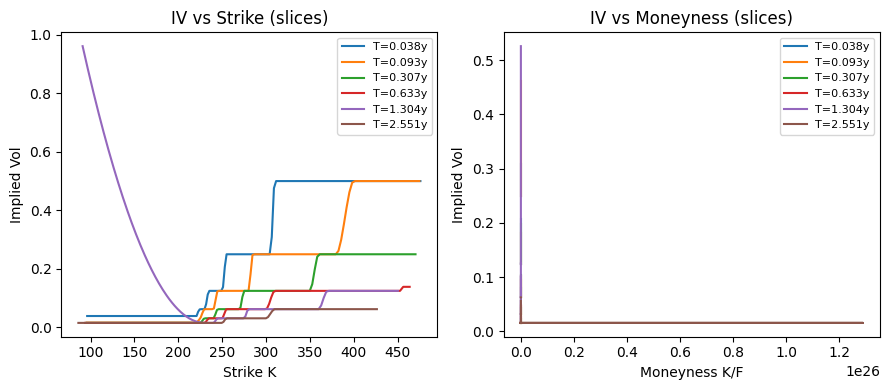

C:\Users\alezu\AppData\Local\Temp\ipykernel_46260\552523557.py:236: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, K)


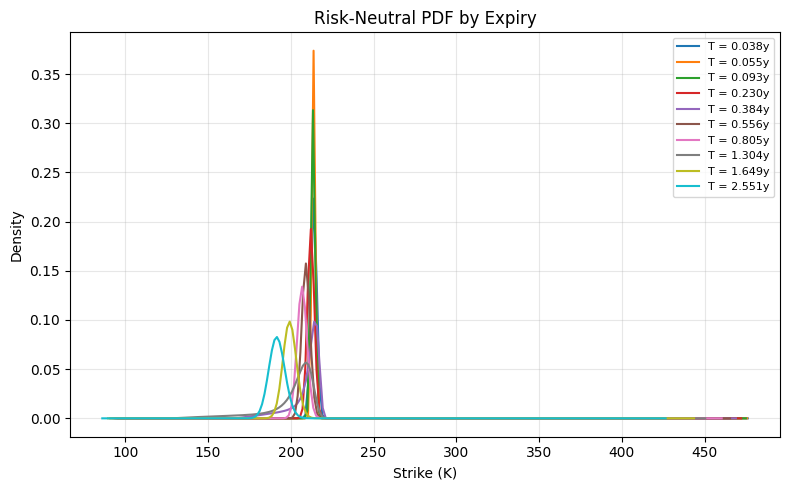

In [15]:
    # Optional: a few slices for quick validation
plot_expiry_slices(Kmat, grid_T, SIGMA, F, n=6)
plot_pdf_slices(Kmat, grid_T, F, n=10)

In [16]:
for ticker in TICKERS:
    try:
        df = load_and_normalise(ticker, db_path=DB_PATH, snapshot_date=SNAPSHOT_DATE)
    except RuntimeError as e:
        print(f"  Skipping {ticker}: {e}")
        continue

    eps = 1e-8
    df["r"] = -np.log(df["disc_factor"].clip(lower=1e-12)) / df["T"].clip(lower=eps)

    deltas = []
    for _, row in df.iterrows():
        delta = bs_delta(
            spot=row["spot"],
            K=row["strike"],
            r=row["r"],
            q=row["div_yield"],
            vol=row["iv"],
            T=row["T"],
            is_call=row["isCall"],
        )
        deltas.append(delta)
    df["delta"] = deltas

    results = []
    for expiry, g in df.groupby("expiry"):
        g = g.copy()
        F_val = g["forward"].median()
        atm_row = g.iloc[(g["strike"] - F_val).abs().argsort().iloc[0]]
        sigma_atm = atm_row["iv"]

        calls = g[g["isCall"]]
        sigma_25c = iv_at_target_delta(calls, 0.25)

        puts = g[~g["isCall"]]
        sigma_25p = iv_at_target_delta(puts, -0.25)

        if pd.notna(sigma_25c) and pd.notna(sigma_25p):
            rr25 = sigma_25c - sigma_25p
            bf25 = (sigma_25c + sigma_25p) / 2.0 - sigma_atm
        else:
            rr25, bf25 = np.nan, np.nan

        results.append(dict(
            expiry=expiry,
            days_to_expiry=round(g["T"].median() * 365),
            T=g["T"].median(),
            sigma_atm=sigma_atm,
            sigma_25c=sigma_25c,
            sigma_25p=sigma_25p,
            rr25=rr25,
            bf25=bf25,
        ))

    out = pd.DataFrame(results).sort_values("expiry").reset_index(drop=True)
    print(f"\n=== {ticker} ===")
    print(out.to_string(index=False))

Loaded 1590 rows  |  NVDA  |  snapshot=2026-05-29

=== NVDA ===
    expiry  days_to_expiry        T  sigma_atm  sigma_25c  sigma_25p      rr25     bf25
2026-06-12              14 0.038356   0.031260   0.250007   0.031260  0.218748 0.109374
2026-06-18              20 0.054795   0.015635   0.031260   1.087264 -1.056004 0.543627
2026-06-26              28 0.076712   0.015635   0.031260   0.125009 -0.093749 0.062499
2026-07-02              34 0.093151   0.015635   0.125009   0.062509  0.062499 0.078124
2026-07-17              49 0.134247   0.015635   0.250007   0.838927 -0.588919 0.528832
2026-08-21              84 0.230137   0.015635   0.015635   0.651879 -0.636245 0.318122
2026-09-18             112 0.306849   0.015635   0.015635   1.656186 -1.640551 0.820276
2026-10-16             140 0.383562   0.015635   0.506113   0.250007  0.256105 0.362425
2026-11-20             175 0.479452   0.015635   0.432975   0.277184  0.155791 0.339445
2026-12-18             203 0.556164   0.015635   0.01563